In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# @title Stock Selection
ticker_symbol = "HDFCBANK.NS" # @param {type:"string"}
period = "2y" # @param ["1y", "2y", "5y", "max"]
interval = "1d" # @param ["1d", "1h"]

def fetch_stock_data(ticker, period='2y', interval='1d'):
    """Fetches historical stock data using yfinance."""
    print(f'Fetching data for {ticker}...')
    df = yf.download(ticker, period=period, interval=interval)
    if df.empty:
        raise ValueError(f"No data found for {ticker}. Please check the ticker symbol (e.g., add .NS for NSE).")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

def add_technical_indicators(df):
    """Adds RSI, EMA, and Bollinger Bands."""
    df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['20SD'] = df['Close'].rolling(window=20).std()
    df['Upper_BB'] = df['MA20'] + (df['20SD'] * 2)
    df['Lower_BB'] = df['MA20'] - (df['20SD'] * 2)

    return df.dropna()

# Execution with user-selected ticker
try:
    df = fetch_stock_data(ticker_symbol, period=period, interval=interval)
    df = add_technical_indicators(df)
    display(df.tail())
except Exception as e:
    print(f"Error: {e}")

Fetching data for HDFCBANK.NS...


/tmp/ipykernel_4067/1035291989.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,EMA_20,EMA_50,RSI,MA20,20SD,Upper_BB,Lower_BB
Date,,,,,,,,,,,,
2026-04-07,772.000000,774.000000,761.000000,766.0,51309793,796.553370,853.290870,41.309383,797.690002,42.517423,882.724848,712.655157
2026-04-08,816.099976,817.799988,796.000000,800.0,70269512,798.414951,851.832403,45.615603,795.642502,40.443832,876.530166,714.754838
2026-04-09,797.700012,819.000000,793.099976,815.0,48879392,798.346862,849.709565,41.869991,793.492502,39.041120,871.574741,715.410262
2026-04-10,810.299988,812.250000,801.000000,804.0,38156026,799.485255,848.164091,44.601942,791.535001,37.016770,865.568540,717.501461
2026-04-13,790.000000,793.950012,787.349976,791.5,20344398,798.581897,845.883146,48.529409,789.337500,35.645422,860.628345,718.046655


### **Real-time Stock Market Predictor**

This notebook will guide you through creating a stock market predictor. We'll cover data acquisition, preprocessing, and building predictive models using `scikit-learn` and `TensorFlow`.

**Note on 'Real-time':** A truly real-time system involves continuous data streams and deployment, which is beyond a typical Colab notebook's direct capabilities. Here, 'real-time' refers to fetching the latest available data and making predictions when the code is executed.

In [17]:
# Install necessary libraries
!pip install yfinance pandas scikit-learn tensorflow matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

### **1. Data Acquisition**

We'll use `yfinance` to download historical stock data. You can change the ticker symbol and date range as needed.

### **2. Data Preprocessing**

Before feeding the data into our models, we need to preprocess it. This involves:
1.  **Feature Selection:** Choosing relevant columns for prediction.
2.  **Handling Missing Values:** Although `yfinance` usually provides clean data, it's a good practice to check.
3.  **Data Scaling:** Normalizing the data to a specific range (e.g., 0-1) is crucial for many machine learning models, especially neural networks.

In [18]:
# Re-run this cell whenever you change the stock ticker above
features = ['Close', 'EMA_20', 'EMA_50', 'RSI', 'Upper_BB', 'Lower_BB']
data = df[features]

# Re-initialize scaler for the new stock's price range
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"Preprocessing complete for {ticker_symbol}")
print(f"Scaled data shape: {scaled_data.shape}")
display(pd.DataFrame(scaled_data, columns=features).tail())

Preprocessing complete for HDFCBANK.NS
Scaled data shape: (475, 6)


,Close,EMA_20,EMA_50,RSI,Upper_BB,Lower_BB
470,0.205586,0.263401,0.475825,0.376877,0.480647,0.066522
471,0.351014,0.270164,0.470332,0.427425,0.457846,0.073655
472,0.290337,0.269917,0.462336,0.383458,0.439606,0.075881
473,0.331888,0.274052,0.456514,0.415526,0.417499,0.082985
474,0.264945,0.270771,0.447923,0.461628,0.399315,0.084837


### **3. Prepare Data for Supervised Learning**

For time series prediction, we often transform the data into a supervised learning problem. This involves creating sequences where past `n` observations (timesteps) are used to predict the next observation.

In [19]:
# Function to create sequences for LSTM using all features
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        # X contains all features for the look-back period
        X.append(data[i:(i + time_steps)])
        # y contains the 'Close' price (index 0) of the next day
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

# Define the number of time steps (look-back period)
time_steps = 60

# Create sequences
X, y = create_sequences(scaled_data, time_steps)

print(f"\nShape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

# Split data into training and testing sets (80% train, 20% test)
# Using shuffle=False to maintain time-series order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")


Shape of X (features): (415, 60, 6)
Shape of y (target): (415,)

Shape of X_train: (332, 60, 6)
Shape of X_test: (83, 60, 6)


### **4. Build and Train Models**

We'll build two types of models:
1.  **Linear Regression:** A simple baseline model.
2.  **Long Short-Term Memory (LSTM) Neural Network:** A more advanced model suitable for sequence prediction.

#### **4.1 Linear Regression Model**

In [20]:
# Reshape X for Linear Regression (flatten the time steps)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_flat, y_train)

# Make predictions
predictions_linear = linear_model.predict(X_test_flat)

# Evaluate
mse_linear = mean_squared_error(y_test, predictions_linear)
rmse_linear = np.sqrt(mse_linear)
print(f"Linear Regression - RMSE: {rmse_linear:.4f}")

Linear Regression - RMSE: 0.0711


#### **4.2 LSTM Model**

LSTM networks are particularly well-suited for time series data because they can learn long-term dependencies.

In [21]:
# Build the LSTM model
# Input shape: (time_steps, number_of_features)
lstm_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
print("Training LSTM...")
history = lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

# Make predictions
predictions_lstm = lstm_model.predict(X_test)

# Evaluate
mse_lstm = mean_squared_error(y_test, predictions_lstm)
rmse_lstm = np.sqrt(mse_lstm)
print(f"\nLSTM - RMSE: {rmse_lstm:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

LSTM - RMSE: 0.1081


### **5. Visualize Predictions**

Let's visualize the predictions of both models against the actual stock prices.

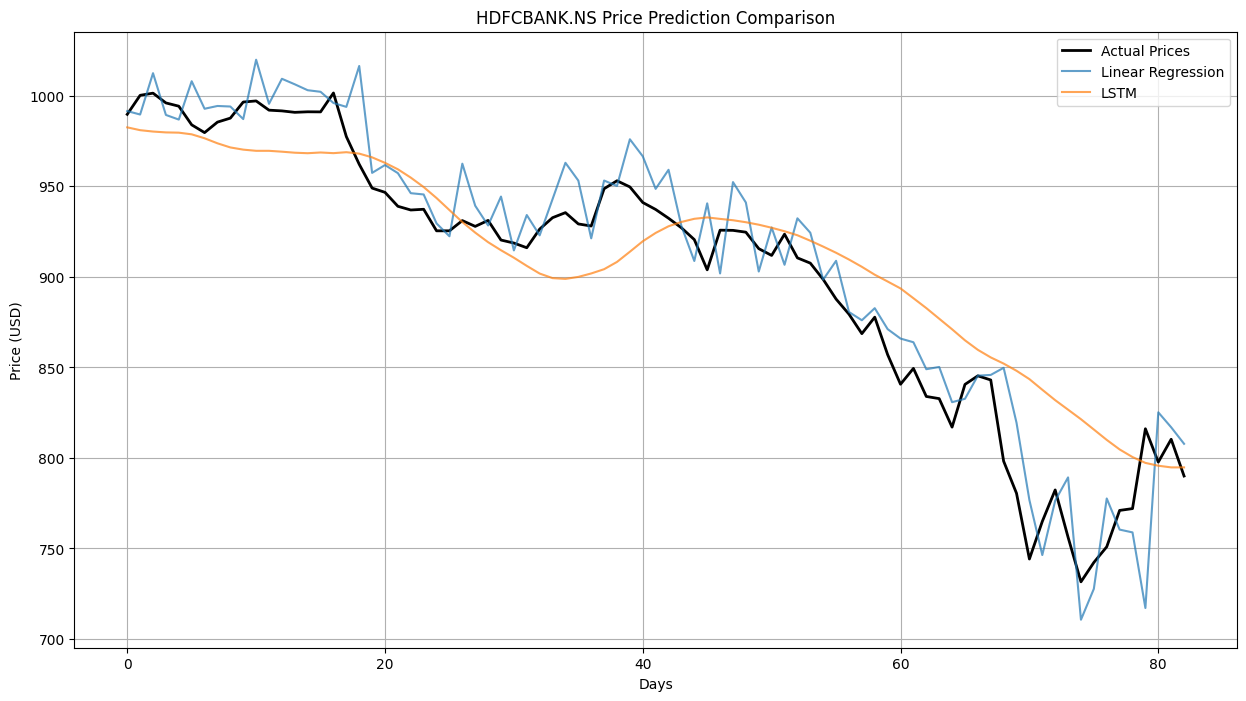

In [22]:
# To inverse transform, we need to provide a dummy array with the same shape as the training features
import numpy as np

def inverse_transform_target(predictions, scaler, num_features):
    # Create a dummy array with the same number of columns as the original scaled data
    dummy = np.zeros((len(predictions), num_features))
    # Place the predictions in the 'Close' column (index 0)
    dummy[:, 0] = predictions.flatten()
    # Inverse transform and extract the first column
    return scaler.inverse_transform(dummy)[:, 0]

# Inverse transform the predictions and actual values
predictions_linear_actual = inverse_transform_target(predictions_linear, scaler, len(features))
predictions_lstm_actual = inverse_transform_target(predictions_lstm, scaler, len(features))
y_test_actual = inverse_transform_target(y_test, scaler, len(features))

# Plotting for comparison
plt.figure(figsize=(15, 8))
plt.plot(y_test_actual, label='Actual Prices', color='black', linewidth=2)
plt.plot(predictions_linear_actual, label='Linear Regression', alpha=0.7)
plt.plot(predictions_lstm_actual, label='LSTM', alpha=0.7)
plt.title(f'{ticker_symbol} Price Prediction Comparison')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

### **6. Make a 'Real-time' Prediction**

Let's predict the next day's stock price based on the latest available data.

In [23]:
# Ensure we use the correct time_steps and features for the selected stock
last_sequence = scaled_data[-time_steps:].reshape(1, time_steps, len(features))

# Predict using the LSTM model
next_day_scaled = lstm_model.predict(last_sequence, verbose=0)

# Inverse transform to get actual price in INR (if .NS or .BO)
next_day_actual = inverse_transform_target(next_day_scaled, scaler, len(features))

currency = "INR" if (".NS" in ticker_symbol or ".BO" in ticker_symbol) else "USD"

print(f"\n--- REAL-TIME PREDICTION FOR {ticker_symbol} ---")
print(f"Latest Closing Price: {currency} {df['Close'].iloc[-1]:.2f}")
print(f"Predicted Next Day Price: {currency} {next_day_actual[0]:.2f}")

signal = "BUY" if next_day_actual[0] > df['Close'].iloc[-1] else "SELL"
print(f"Action Signal: {signal}")


--- REAL-TIME PREDICTION FOR HDFCBANK.NS ---
Latest Closing Price: INR 790.00
Predicted Next Day Price: INR 795.34
Action Signal: BUY


### **Summary and Next Steps**

We have successfully:
1.  Acquired historical stock data.
2.  Preprocessed the data, including scaling and creating sequences.
3.  Built and trained both a Linear Regression model and an LSTM model.
4.  Visualized their predictions.
5.  Made a prediction for the next trading day.

**Potential Enhancements:**
*   **More Features:** Incorporate additional technical indicators (e.g., Moving Averages, RSI, MACD), fundamental data, or sentiment analysis.
*   **Hyperparameter Tuning:** Optimize LSTM parameters (e.g., number of layers, units, dropout rate, epochs, batch size).
*   **More Advanced Models:** Explore other deep learning architectures (e.g., GRU, Transformers) or ensemble methods.
*   **Robust Evaluation:** Use metrics like R-squared, MAE, and consider financial metrics relevant to trading strategies.
*   **Deployment:** For a truly 'real-time' system, integrate with live data feeds and deploy the model to a cloud platform for continuous predictions.